# HW10-11: Классификация (CIFAR-100) + Сегментация (OxfordIIITPet)

**Часть A (S10):** Классификация изображений — CNN с нуля, аугментации, Transfer Learning на ResNet18.

**Часть B (S11):** Семантическая сегментация — OxfordIIITPet с pretrained DeepLabV3.

Датасеты: `CIFAR-100` (Part A), `OxfordIIITPet` (Part B).

## 1. Импорты, seed и устройство

In [1]:
import os
import json
import math
import time
import random
import csv
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights

print(f"torch:       {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

torch:       2.10.0+cu128
torchvision: 0.25.0+cu128
torch:       2.10.0+cu128
torchvision: 0.25.0+cu128


In [2]:
RANDOM_STATE = 42

def set_seed(seed: int = 42) -> None:
    """Фиксируем все генераторы случайных чисел для воспроизводимости."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")

DATA_DIR      = Path("./data")
ARTIFACTS_DIR = Path("./artifacts")
FIGURES_DIR   = ARTIFACTS_DIR / "figures"

DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FAST_MODE = False

print(f"FAST_MODE: {FAST_MODE}")

Device: cuda
Device: cuda
GPU:    Tesla T4
FAST_MODE: False
GPU:    Tesla T4
FAST_MODE: False


## 2. Данные и DataLoader — Часть A: CIFAR-100

In [3]:
# CIFAR-100 статистики (посчитаны по train-split)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# C3/C4: preprocessing для ResNet18 pretrained (ImageNet)
weights_rn18   = ResNet18_Weights.DEFAULT
transform_rn18 = weights_rn18.transforms()   # Resize(256) → CenterCrop(224) → Normalize(ImageNet)

# ResNet + аугментации (для C4)
transform_rn18_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("transform_base:",  transform_base)
print()
print("transform_aug:",   transform_aug)
print()
print("transform_rn18:",  transform_rn18)

transform_base: Compose(
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)

transform_aug: Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)

transform_rn18: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
transform_base: Compose(
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)

transform_aug: Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)

transform_r

In [4]:
# Загрузка CIFAR-100

VAL_FRACTION = 0.2
BATCH_SIZE   = 128
NUM_CLASSES  = 100

def make_cifar100_loaders(
    train_transform,
    val_test_transform=transform_base,
    batch_size: int = BATCH_SIZE,
    val_fraction: float = VAL_FRACTION,
    seed: int = RANDOM_STATE,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Возвращает (train_loader, val_loader, test_loader) для CIFAR-100."""
    full_train = datasets.CIFAR100(
        root=DATA_DIR, train=True, download=True, transform=train_transform
    )
    test_ds = datasets.CIFAR100(
        root=DATA_DIR, train=False, download=True, transform=val_test_transform
    )

    # Разбиение train → train/val (фиксированный seed)
    n_total = len(full_train)
    n_val   = int(n_total * val_fraction)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(full_train, [n_train, n_val], generator=generator)

    full_train_val = datasets.CIFAR100(
        root=DATA_DIR, train=True, download=False, transform=val_test_transform
    )
    val_ds_clean = Subset(full_train_val, val_ds.indices)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds_clean, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"Train: {len(train_ds):>6} | Val: {len(val_ds_clean):>6} | Test: {len(test_ds):>6}")
    return train_loader, val_loader, test_loader


# Loaders для C1 (без аугментаций)
train_loader_base, val_loader, test_loader = make_cifar100_loaders(transform_base)

100%|██████████| 169M/169M [00:13<00:00, 12.8MB/s]



Train:  40000 | Val:  10000 | Test:  10000
Train:  40000 | Val:  10000 | Test:  10000


In [5]:
# Sanity check
x_batch, y_batch = next(iter(train_loader_base))
print(f"x.shape: {x_batch.shape}  dtype: {x_batch.dtype}")
print(f"y.shape: {y_batch.shape}  dtype: {y_batch.dtype}")
print(f"x range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"Unique labels in batch: {y_batch.unique().numel()}")

# Список имён классов CIFAR-100
cifar100_classes = datasets.CIFAR100(root=DATA_DIR, train=True, download=False).classes
print(f"\nTotal classes: {len(cifar100_classes)}")
print(f"First 10: {cifar100_classes[:10]}")

x.shape: torch.Size([128, 3, 32, 32])  dtype: torch.float32
y.shape: torch.Size([128])  dtype: torch.int64
x range: [-1.897, 2.025]
Unique labels in batch: 75

Total classes: 100
First 10: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']


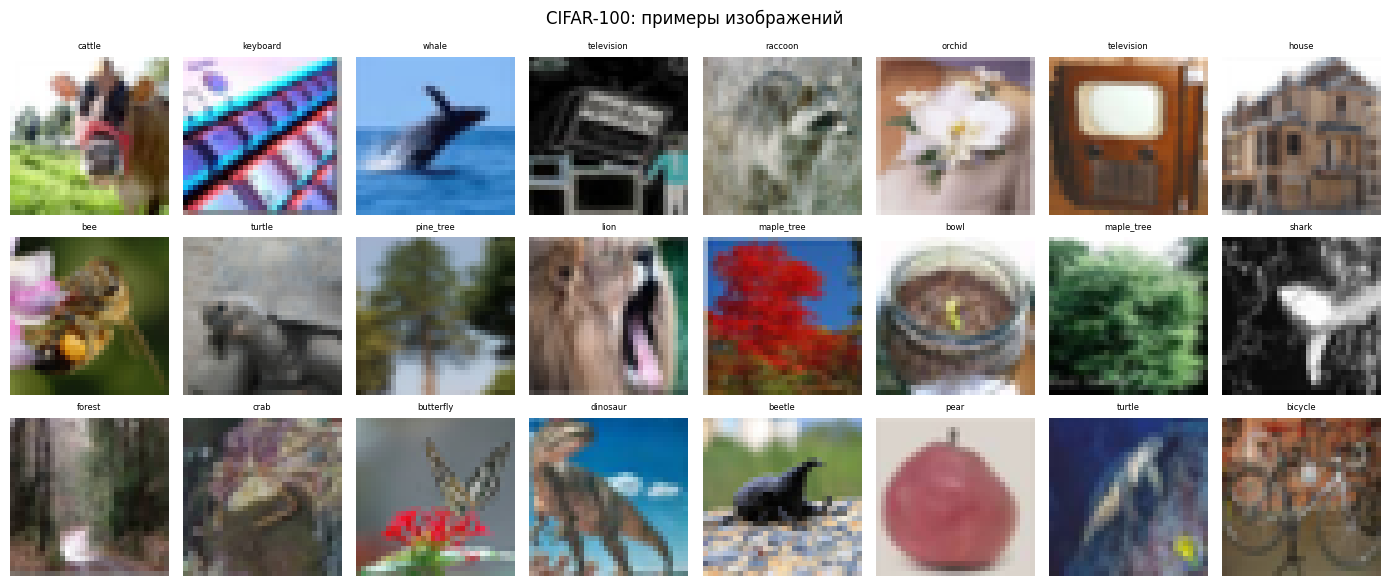

In [6]:
#Визуализация примеров CIFAR-100
def denormalize(tensor, mean, std):
    """Обратная нормализация для визуализации."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


# нормализованный датасет с train=True для имён классов
raw_ds = datasets.CIFAR100(root=DATA_DIR, train=True, download=False,
                            transform=transforms.ToTensor())

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
axes = axes.flatten()
for i, ax in enumerate(axes):
    img, label = raw_ds[i * 200]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(cifar100_classes[label], fontsize=6)
    ax.axis("off")

fig.suptitle("CIFAR-100: примеры изображений", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cifar100_samples.png", dpi=120, bbox_inches="tight")
plt.show()

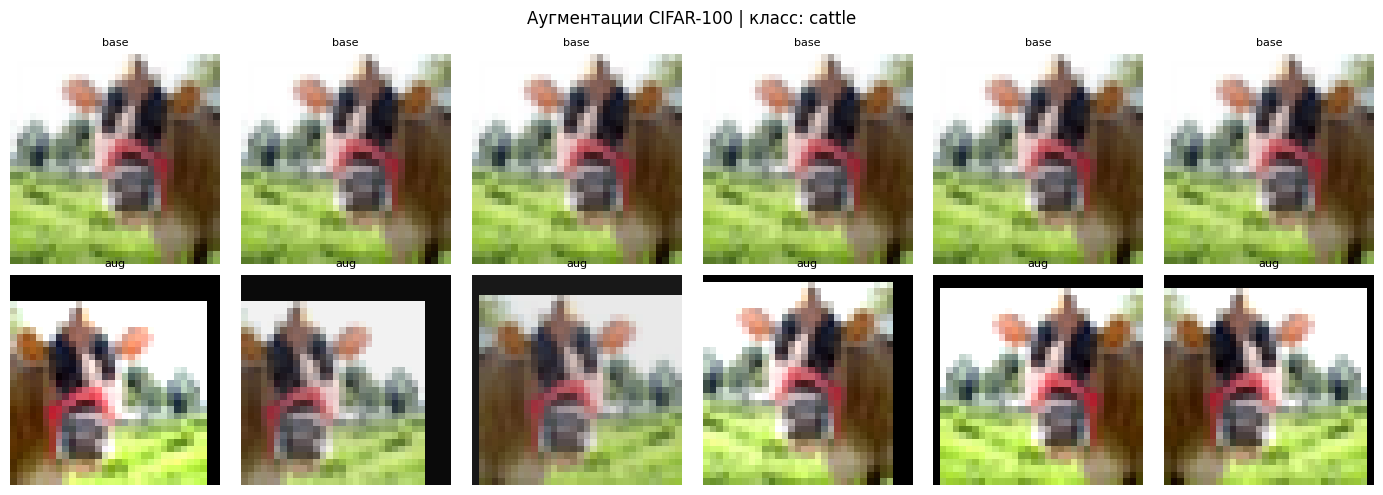

Сохранено: artifacts/figures/augmentations_preview.png


In [7]:
# Визуализация аугментаций
orig_img, orig_label = raw_ds[0]   # PIL-like tensor [0,1]
orig_pil = transforms.ToPILImage()(orig_img)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for ax in axes[0]:
    t = transform_base(orig_pil)
    img_vis = denormalize(t, CIFAR100_MEAN, CIFAR100_STD)
    ax.imshow(img_vis.permute(1, 2, 0).numpy())
    ax.set_title("base", fontsize=8)
    ax.axis("off")

# Нижний ряд: augmented transform
for ax in axes[1]:
    t = transform_aug(orig_pil)
    img_vis = denormalize(t, CIFAR100_MEAN, CIFAR100_STD)
    ax.imshow(img_vis.permute(1, 2, 0).numpy())
    ax.set_title("aug", fontsize=8)
    ax.axis("off")

fig.suptitle(f"Аугментации CIFAR-100 | класс: {cifar100_classes[orig_label]}", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/augmentations_preview.png")

## 3. Базовые функции обучения и оценки (Часть A)

In [8]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device = DEVICE,
) -> Tuple[float, float]:
    """Одна эпоха обучения. Возвращает (avg_loss, accuracy)."""
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_seen    += x.size(0)

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device = DEVICE,
) -> Tuple[float, float]:
    """Оценка на любом DataLoader. Возвращает (avg_loss, accuracy)."""
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)

        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_seen    += x.size(0)

    return total_loss / total_seen, total_correct / total_seen


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    epochs: int = 10,
    verbose: bool = True,
) -> Dict[str, List[float]]:
    """Полный цикл обучения. Возвращает историю метрик."""
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if verbose:
            print(f"Epoch {epoch:>3}/{epochs}  "
                  f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
                  f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  "
                  f"[{elapsed:.1f}s]")

    return history


def plot_history(
    history: Dict[str, List[float]],
    title: str = "",
    save_path: Optional[Path] = None,
) -> None:
    """Рисует кривые loss и accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="val")
    axes[0].set_title(f"Loss — {title}")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"],   label="val")
    axes[1].set_title(f"Accuracy — {title}")
    axes[1].set_xlabel("Epoch"); axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


print("Функции обучения определены.")

Функции обучения определены.
Функции обучения определены.


## 4. Эксперименты Части A: C1–C4

### 4.1. Архитектура SimpleCNN (используется в C1 и C2)

In [9]:
class SimpleCNN(nn.Module):
    """Простая CNN для CIFAR-100 (32×32 RGB)."""

    def __init__(self, num_classes: int = 100):
        super().__init__()
        # Feature extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2),            # 32 → 16
            nn.Dropout2d(0.1),
            # Block 2
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),            # 16 → 8
            nn.Dropout2d(0.1),
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),            # 8 → 4
            nn.Dropout2d(0.2),
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


# Проверка формы
_m = SimpleCNN(NUM_CLASSES)
_x = torch.zeros(2, 3, 32, 32)
print(f"Выходной shape: {_m(_x).shape}")
print(f"Параметров:     {count_params(_m):,}")
del _m, _x

Выходной shape: torch.Size([2, 100])
Параметров:     3,296,164


C1 (simple-cnn-base) | epochs=30 | lr=0.001
Epoch   1/30  train_loss=4.1461  train_acc=0.0597  val_loss=3.6852  val_acc=0.1375  [14.4s]
Epoch   2/30  train_loss=3.7085  train_acc=0.1173  val_loss=3.3405  val_acc=0.1929  [14.6s]
Epoch   3/30  train_loss=3.4938  train_acc=0.1510  val_loss=3.1034  val_acc=0.2260  [13.2s]
Epoch   4/30  train_loss=3.3011  train_acc=0.1846  val_loss=2.9476  val_acc=0.2636  [13.1s]
Epoch   5/30  train_loss=3.1190  train_acc=0.2109  val_loss=2.7030  val_acc=0.3009  [13.5s]
Epoch   6/30  train_loss=2.9501  train_acc=0.2432  val_loss=2.5351  val_acc=0.3328  [13.2s]
Epoch   7/30  train_loss=2.8209  train_acc=0.2697  val_loss=2.4084  val_acc=0.3631  [13.3s]
Epoch   8/30  train_loss=2.6815  train_acc=0.2965  val_loss=2.3191  val_acc=0.3776  [13.4s]
Epoch   9/30  train_loss=2.5859  train_acc=0.3114  val_loss=2.1950  val_acc=0.4114  [13.3s]
Epoch  10/30  train_loss=2.4818  train_acc=0.3365  val_loss=2.1246  val_acc=0.4238  [13.2s]
Epoch  11/30  train_loss=2.3765  tra

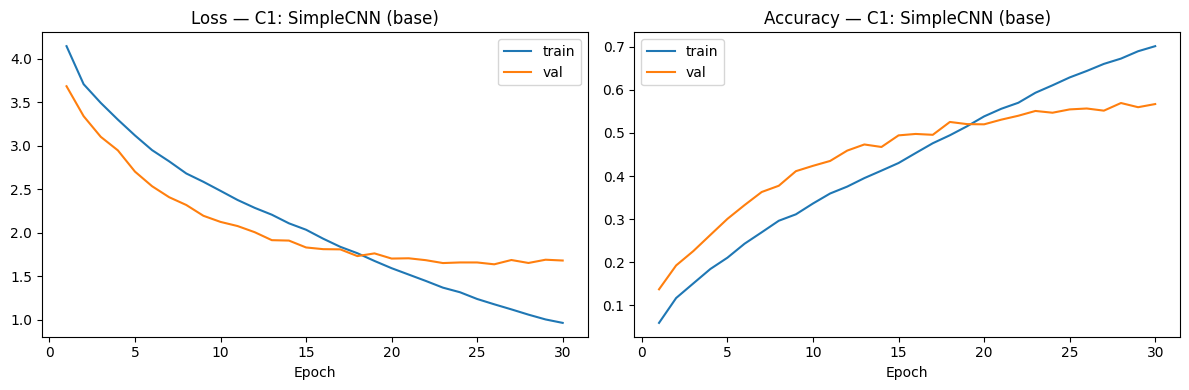

In [10]:
# C1: SimpleCNN, без аугментаций
EPOCHS_CNN = 5 if FAST_MODE else 30
LR_CNN     = 1e-3

set_seed(RANDOM_STATE)

print("=" * 70)
print(f"C1 (simple-cnn-base) | epochs={EPOCHS_CNN} | lr={LR_CNN}")
print("=" * 70)

model_c1 = SimpleCNN(NUM_CLASSES).to(DEVICE)
optim_c1 = torch.optim.Adam(model_c1.parameters(), lr=LR_CNN, weight_decay=1e-4)

hist_c1 = fit(model_c1, train_loader_base, val_loader, optim_c1, criterion,
              epochs=EPOCHS_CNN)

best_val_c1 = max(hist_c1["val_acc"])
print(f"\nC1 best_val_acc = {best_val_c1:.4f}")
plot_history(hist_c1, title="C1: SimpleCNN (base)")

Train:  40000 | Val:  10000 | Test:  10000
C2 (simple-cnn-aug) | epochs=30 | lr=0.001
Train:  40000 | Val:  10000 | Test:  10000
C2 (simple-cnn-aug) | epochs=30 | lr=0.001
Epoch   1/30  train_loss=4.2843  train_acc=0.0441  val_loss=3.8601  val_acc=0.0963  [26.1s]
Epoch   1/30  train_loss=4.2843  train_acc=0.0441  val_loss=3.8601  val_acc=0.0963  [26.1s]
Epoch   2/30  train_loss=3.9712  train_acc=0.0761  val_loss=3.6444  val_acc=0.1338  [30.4s]
Epoch   2/30  train_loss=3.9712  train_acc=0.0761  val_loss=3.6444  val_acc=0.1338  [30.4s]
Epoch   3/30  train_loss=3.8055  train_acc=0.1007  val_loss=3.4583  val_acc=0.1668  [26.6s]
Epoch   3/30  train_loss=3.8055  train_acc=0.1007  val_loss=3.4583  val_acc=0.1668  [26.6s]
Epoch   4/30  train_loss=3.6755  train_acc=0.1183  val_loss=3.2576  val_acc=0.2070  [27.4s]
Epoch   4/30  train_loss=3.6755  train_acc=0.1183  val_loss=3.2576  val_acc=0.2070  [27.4s]
Epoch   5/30  train_loss=3.5419  train_acc=0.1402  val_loss=3.1200  val_acc=0.2159  [27.1s]


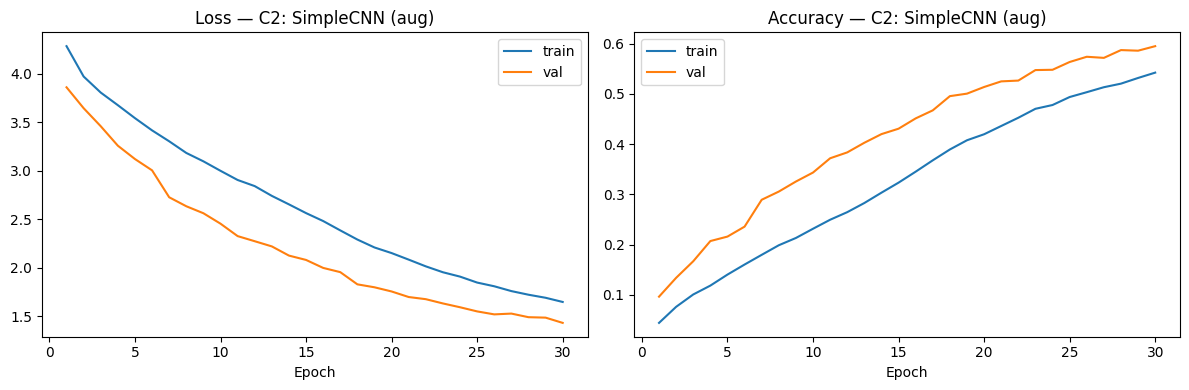

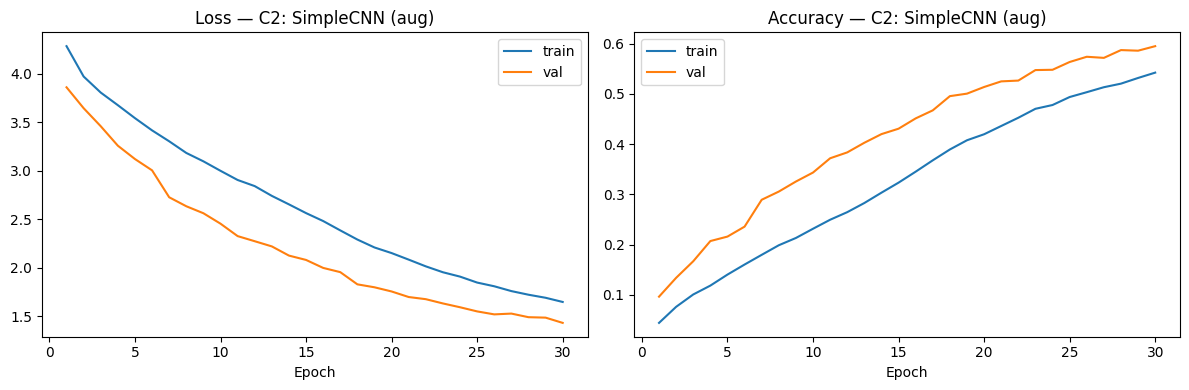

In [11]:
# C2: SimpleCNN, с аугментациями
# Та же архитектура, другой transform для train

train_loader_aug, _, _ = make_cifar100_loaders(transform_aug)  # val/test те же

set_seed(RANDOM_STATE)

print("=" * 70)
print(f"C2 (simple-cnn-aug) | epochs={EPOCHS_CNN} | lr={LR_CNN}")
print("=" * 70)

model_c2 = SimpleCNN(NUM_CLASSES).to(DEVICE)
optim_c2 = torch.optim.Adam(model_c2.parameters(), lr=LR_CNN, weight_decay=1e-4)

hist_c2 = fit(model_c2, train_loader_aug, val_loader, optim_c2, criterion,
              epochs=EPOCHS_CNN)

best_val_c2 = max(hist_c2["val_acc"])
print(f"\nC2 best_val_acc = {best_val_c2:.4f}")
plot_history(hist_c2, title="C2: SimpleCNN (aug)")

Train:  40000 | Val:  10000 | Test:  10000
C3 (resnet18-head-only) | epochs=10 | lr=0.001
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


Обучаемых параметров: 51,300  (из 11,227,812 всего)
Epoch   1/10  train_loss=2.9216  train_acc=0.3319  val_loss=2.1208  val_acc=0.4707  [100.4s]
Epoch   2/10  train_loss=1.9742  train_acc=0.4962  val_loss=1.8329  val_acc=0.5126  [99.8s]
Epoch   3/10  train_loss=1.7863  train_acc=0.5265  val_loss=1.7387  val_acc=0.5330  [102.0s]
Epoch   4/10  train_loss=1.6919  train_acc=0.5441  val_loss=1.6838  val_acc=0.5418  [101.1s]
Epoch   5/10  train_loss=1.6325  train_acc=0.5568  val_loss=1.6676  val_acc=0.5394  [100.9s]
Epoch   6/10  train_loss=1.5894  train_acc=0.5672  val_loss=1.6491  val_acc=0.5471  [101.5s]
Epoch   7/10  train_loss=1.5589  train_acc=0.5747  val_loss=1.6249  val_acc=0.5567  [101.7s]
Epoch   8/10  train_loss=1.5393  train_acc=0.5759  val_loss=1.6183  val_acc=0.5557  [101.5s]
Epoch   9/10  train_loss=1.5143  train_acc=0.5823  val_loss=1.6110  val_acc=0.5562  [101.6s]
Epoch  10/10  train_loss=1.5027  train_acc=0.5863  val_loss=1.6018  val_acc=0.5592  [100.8s]

C3 best_val_acc = 

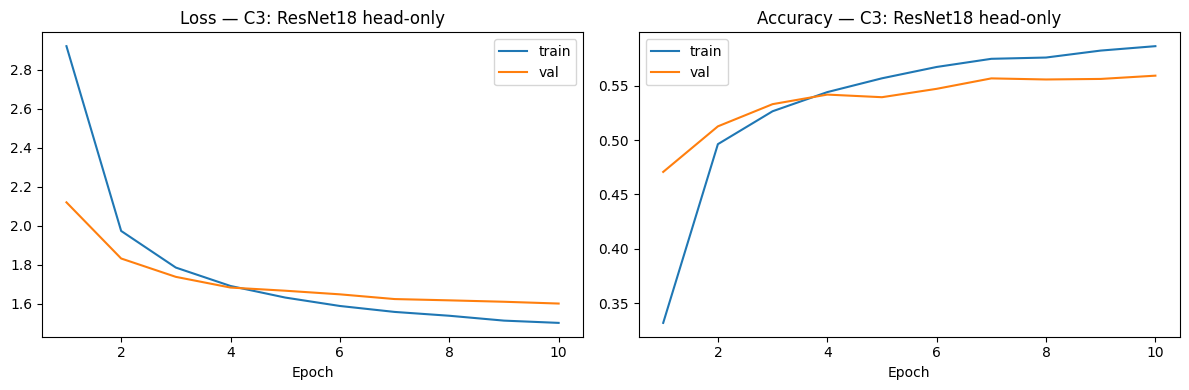

In [12]:
# C3: ResNet18, frozen backbone, обучаем только head
EPOCHS_HEAD = 3 if FAST_MODE else 10
LR_HEAD     = 1e-3

# DataLoader с ResNet-preprocessingом
train_loader_rn, val_loader_rn, test_loader_rn = make_cifar100_loaders(
    transform_rn18_aug, val_test_transform=transform_rn18
)

def build_resnet18_frozen(num_classes: int = 100) -> nn.Module:
    """ResNet18 pretrained, backbone заморожен, только fc обучается."""
    model = resnet18(weights=weights_rn18)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

set_seed(RANDOM_STATE)

print("=" * 70)
print(f"C3 (resnet18-head-only) | epochs={EPOCHS_HEAD} | lr={LR_HEAD}")
print("=" * 70)

model_c3 = build_resnet18_frozen(NUM_CLASSES).to(DEVICE)
print(f"Обучаемых параметров: {count_params(model_c3):,}  "
      f"(из {sum(p.numel() for p in model_c3.parameters()):,} всего)")

optim_c3 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_c3.parameters()),
    lr=LR_HEAD
)

hist_c3 = fit(model_c3, train_loader_rn, val_loader_rn, optim_c3, criterion,
              epochs=EPOCHS_HEAD)

best_val_c3 = max(hist_c3["val_acc"])
print(f"\nC3 best_val_acc = {best_val_c3:.4f}")
plot_history(hist_c3, title="C3: ResNet18 head-only")

C4 (resnet18-finetune layer4+fc) | epochs=10 | lr=0.0003
Обучаемых параметров: 8,445,028  (из 11,227,812 всего)
Epoch   1/10  train_loss=2.8869  train_acc=0.3492  val_loss=1.8372  val_acc=0.5302  [103.8s]
Epoch   2/10  train_loss=1.5937  train_acc=0.5809  val_loss=1.4116  val_acc=0.6058  [104.0s]
Epoch   3/10  train_loss=1.2765  train_acc=0.6479  val_loss=1.2511  val_acc=0.6384  [103.3s]
Epoch   4/10  train_loss=1.1013  train_acc=0.6897  val_loss=1.1511  val_acc=0.6676  [103.1s]
Epoch   5/10  train_loss=0.9765  train_acc=0.7220  val_loss=1.0963  val_acc=0.6820  [103.1s]
Epoch   6/10  train_loss=0.8759  train_acc=0.7483  val_loss=1.0701  val_acc=0.6880  [106.5s]
Epoch   6/10  train_loss=0.8759  train_acc=0.7483  val_loss=1.0701  val_acc=0.6880  [106.5s]
Epoch   7/10  train_loss=0.7957  train_acc=0.7693  val_loss=1.0251  val_acc=0.7028  [104.5s]
Epoch   7/10  train_loss=0.7957  train_acc=0.7693  val_loss=1.0251  val_acc=0.7028  [104.5s]
Epoch   8/10  train_loss=0.7306  train_acc=0.7859  

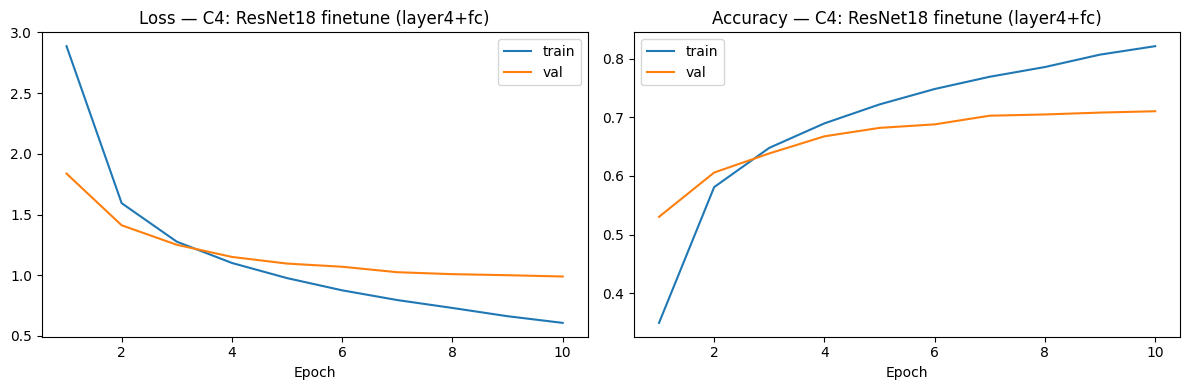

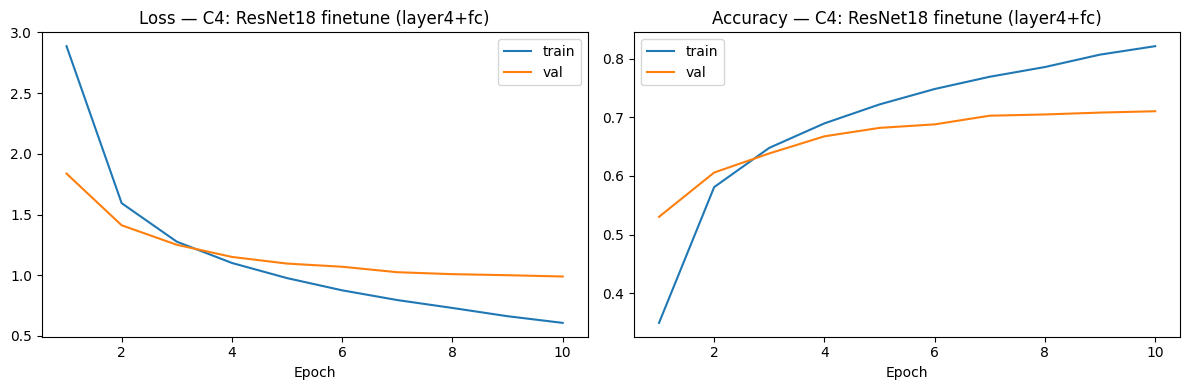

In [13]:
# C4: ResNet18, partial fine-tune (layer4 + fc)
EPOCHS_FT = 3 if FAST_MODE else 10
LR_FT     = 3e-4

def build_resnet18_finetune(num_classes: int = 100) -> nn.Module:
    """ResNet18 pretrained, размораживаем layer4 + fc."""
    model = resnet18(weights=weights_rn18)
    # Сначала заморозить всё
    for p in model.parameters():
        p.requires_grad = False
    # Разморозить layer4 и fc
    for p in model.layer4.parameters():
        p.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    # fc инициализируется уже разморозив
    return model

set_seed(RANDOM_STATE)

print("=" * 70)
print(f"C4 (resnet18-finetune layer4+fc) | epochs={EPOCHS_FT} | lr={LR_FT}")
print("=" * 70)

model_c4 = build_resnet18_finetune(NUM_CLASSES).to(DEVICE)
print(f"Обучаемых параметров: {count_params(model_c4):,}  "
      f"(из {sum(p.numel() for p in model_c4.parameters()):,} всего)")

# Разные lr для backbone и head
optim_c4 = torch.optim.Adam([
    {"params": model_c4.layer4.parameters(), "lr": LR_FT * 0.1},
    {"params": model_c4.fc.parameters(),     "lr": LR_FT},
])

hist_c4 = fit(model_c4, train_loader_rn, val_loader_rn, optim_c4, criterion,
              epochs=EPOCHS_FT)

best_val_c4 = max(hist_c4["val_acc"])
print(f"\nC4 best_val_acc = {best_val_c4:.4f}")
plot_history(hist_c4, title="C4: ResNet18 finetune (layer4+fc)")

In [ ]:
# Сравнение C1–C4
results_partA = {
    "C1": {"name": "simple-cnn-base",       "history": hist_c1, "val_acc": best_val_c1, "model": model_c1, "loader": (train_loader_base, val_loader,  test_loader)},
    "C2": {"name": "simple-cnn-aug",         "history": hist_c2, "val_acc": best_val_c2, "model": model_c2, "loader": (train_loader_aug,  val_loader,  test_loader)},
    "C3": {"name": "resnet18-head-only",     "history": hist_c3, "val_acc": best_val_c3, "model": model_c3, "loader": (train_loader_rn,   val_loader_rn, test_loader_rn)},
    "C4": {"name": "resnet18-finetune",      "history": hist_c4, "val_acc": best_val_c4, "model": model_c4, "loader": (train_loader_rn,   val_loader_rn, test_loader_rn)},
}

print("\n" + "=" * 50)
print("Итоги Части A — best_val_accuracy:")
print("=" * 50)
for eid, r in results_partA.items():
    print(f"  {eid} ({r['name']:<24}): {r['val_acc']:.4f}")

best_exp_id = max(results_partA, key=lambda k: results_partA[k]["val_acc"])
print(f"\nЛучший эксперимент: {best_exp_id} ({results_partA[best_exp_id]['name']})")


Итоги Части A — best_val_accuracy:
  C1 (simple-cnn-base         ): 0.5694
  C2 (simple-cnn-aug          ): 0.5950
  C3 (resnet18-head-only      ): 0.5592
  C4 (resnet18-finetune       ): 0.7104

Лучший эксперимент: C4 (resnet18-finetune)


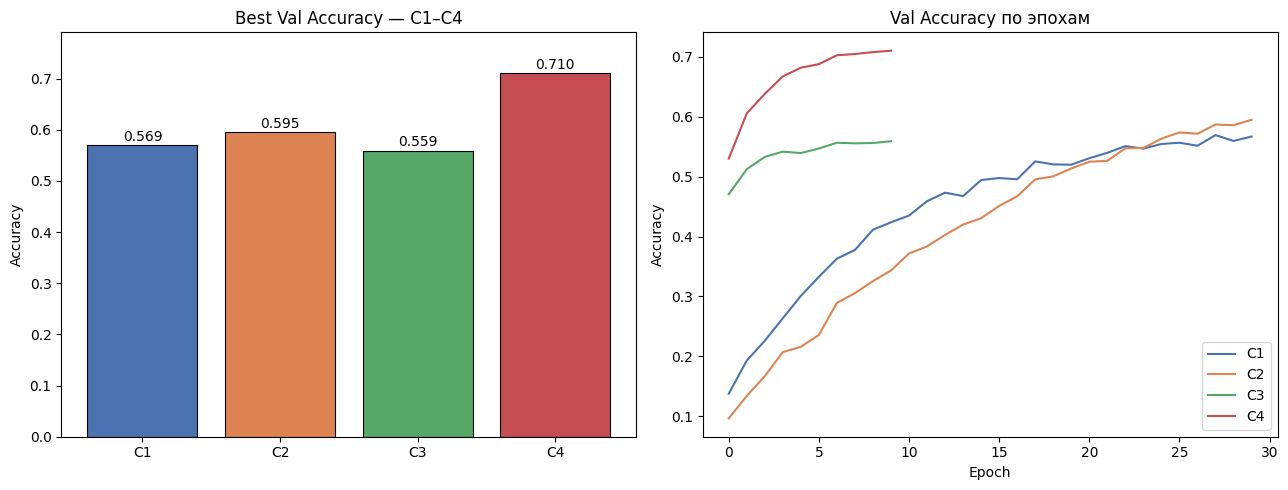

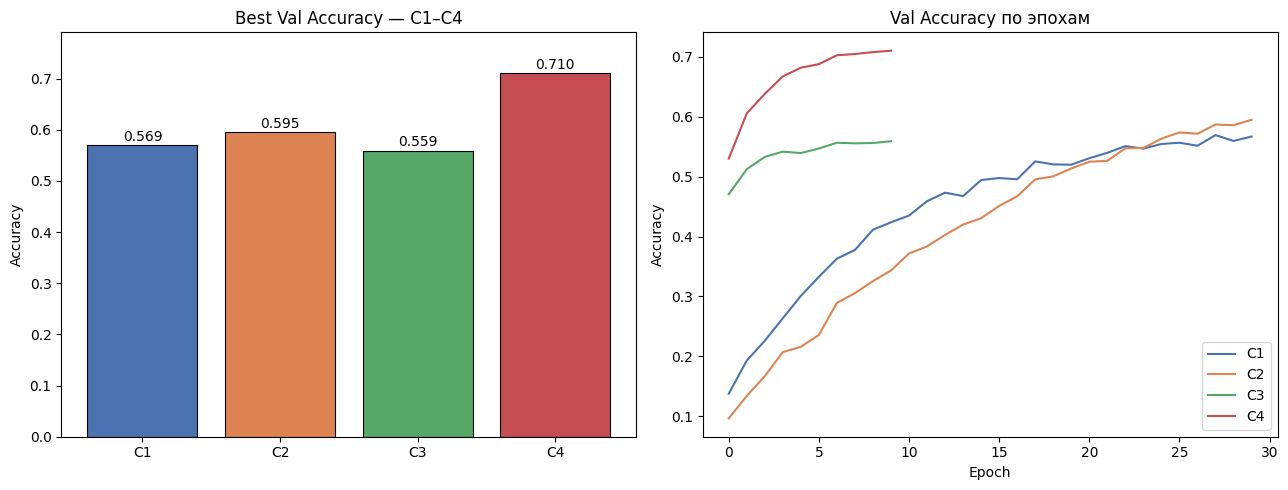

Сохранено: artifacts/figures/classification_compare.png
Сохранено: artifacts/figures/classification_compare.png


In [15]:
# График classification_compare.png
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

exp_ids = list(results_partA.keys())
val_accs = [results_partA[e]["val_acc"] for e in exp_ids]
colors   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

bars = axes[0].bar(exp_ids, val_accs, color=colors, edgecolor="black", linewidth=0.8)
for bar, acc in zip(bars, val_accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{acc:.3f}", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Best Val Accuracy — C1–C4")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, min(1.0, max(val_accs) + 0.08))

# Кривые val_acc по эпохам
for eid, color in zip(exp_ids, colors):
    axes[1].plot(results_partA[eid]["history"]["val_acc"],
                 label=eid, color=color)
axes[1].set_title("Val Accuracy по эпохам")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/classification_compare.png")

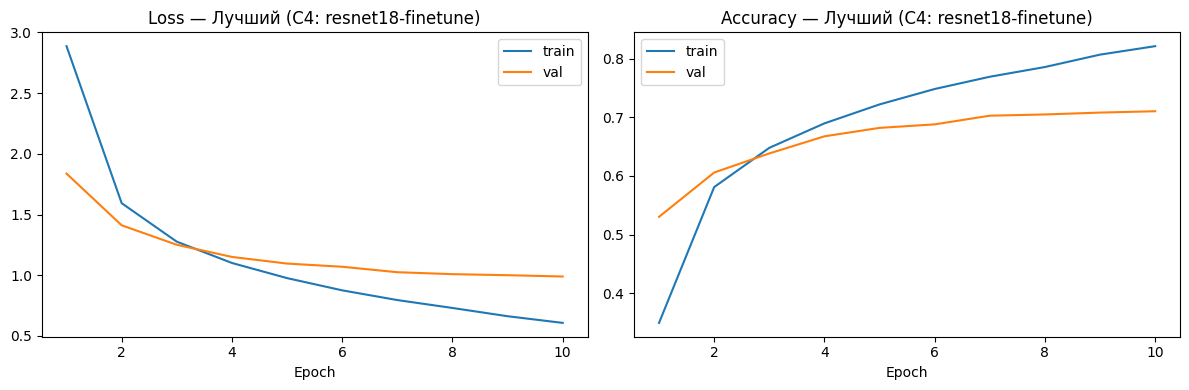

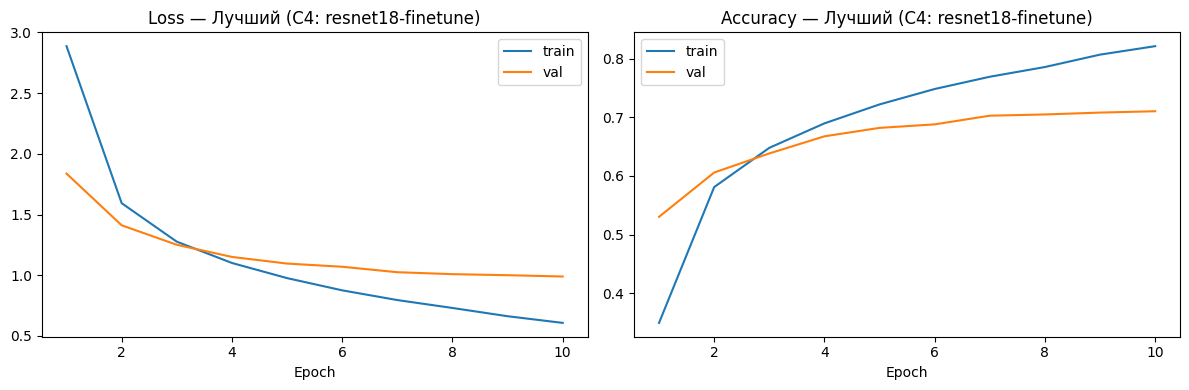

Сохранено: artifacts/figures/classification_curves_best.png
Сохранено: artifacts/figures/classification_curves_best.png


In [16]:
# График лучшего эксперимента
best_hist = results_partA[best_exp_id]["history"]
plot_history(
    best_hist,
    title=f"Лучший ({best_exp_id}: {results_partA[best_exp_id]['name']})",
    save_path=FIGURES_DIR / "classification_curves_best.png",
)
print("Сохранено: artifacts/figures/classification_curves_best.png")

In [17]:

best_model  = results_partA[best_exp_id]["model"]
_, _, best_test_loader = results_partA[best_exp_id]["loader"]

_, test_acc = evaluate(best_model, best_test_loader, criterion)
print(f"TEST accuracy лучшей модели ({best_exp_id}): {test_acc:.4f}")

TEST accuracy лучшей модели (C4): 0.7164
TEST accuracy лучшей модели (C4): 0.7164


In [18]:

torch.save(best_model.state_dict(), ARTIFACTS_DIR / "best_classifier.pt")
print("Сохранено: artifacts/best_classifier.pt")

config = {
    "experiment_id":  best_exp_id,
    "model_name":     results_partA[best_exp_id]["name"],
    "dataset":        "CIFAR-100",
    "num_classes":    NUM_CLASSES,
    "seed":           RANDOM_STATE,
    "batch_size":     BATCH_SIZE,
    "epochs_trained": EPOCHS_HEAD if best_exp_id in ("C3", "C4") else EPOCHS_CNN,
    "optimizer":      "Adam",
    "lr":             LR_HEAD if best_exp_id in ("C3", "C4") else LR_CNN,
    "weight_decay":   "1e-4 (CNN) / 0 (ResNet)",
    "val_split":      VAL_FRACTION,
    "best_val_acc":   round(results_partA[best_exp_id]["val_acc"], 6),
    "test_acc":       round(test_acc, 6),
    "transforms":     {
        "C1/C2_base": str(transform_base),
        "C2_aug":     str(transform_aug),
        "C3/C4_rn18": str(transform_rn18),
    },
}

with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Сохранено: artifacts/best_classifier_config.json")

Сохранено: artifacts/best_classifier.pt
Сохранено: artifacts/best_classifier_config.json
Сохранено: artifacts/best_classifier.pt
Сохранено: artifacts/best_classifier_config.json


## 5. Часть B (S11): Сегментация — OxfordIIITPet

In [19]:
# ── OxfordIIITPet — загрузка данных ──────────────────────────────────────────
# target_types='segmentation' → PIL-маска с 3 значениями:
#   1 = foreground (питомец)
#   2 = background
#   3 = border / не определено
#
# Foreground-сценарий: класс 1 (силуэт животного)

from torchvision.datasets import OxfordIIITPet

# Загрузка (train split)
pet_ds = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="segmentation",
    download=True,
)

print(f"Датасет OxfordIIITPet (trainval): {len(pet_ds)} изображений")


img_pil, mask_pil = pet_ds[0]
print(f"Изображение: {img_pil.size}, mode={img_pil.mode}")
print(f"Маска:       {mask_pil.size}, mode={mask_pil.mode}")

mask_np = np.array(mask_pil)
print(f"Уникальные значения в маске: {np.unique(mask_np)}")
print("  1 = foreground (питомец)")
print("  2 = background")
print("  3 = border/неопределённо")

100%|██████████| 792M/792M [00:45<00:00, 17.5MB/s]

100%|██████████| 19.2M/19.2M [00:02<00:00, 8.82MB/s]



Датасет OxfordIIITPet (trainval): 3680 изображений
Изображение: (394, 500), mode=RGB
Маска:       (394, 500), mode=L
Уникальные значения в маске: [1 2 3]
  1 = foreground (питомец)
  2 = background
  3 = border/неопределённо
Датасет OxfordIIITPet (trainval): 3680 изображений
Изображение: (394, 500), mode=RGB
Маска:       (394, 500), mode=L
Уникальные значения в маске: [1 2 3]
  1 = foreground (питомец)
  2 = background
  3 = border/неопределённо


/tmp/ipykernel_3358/1426408005.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mask = plt.cm.get_cmap("Set1", 4)  # цвета для 1/2/3
/tmp/ipykernel_3358/1426408005.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mask = plt.cm.get_cmap("Set1", 4)  # цвета для 1/2/3


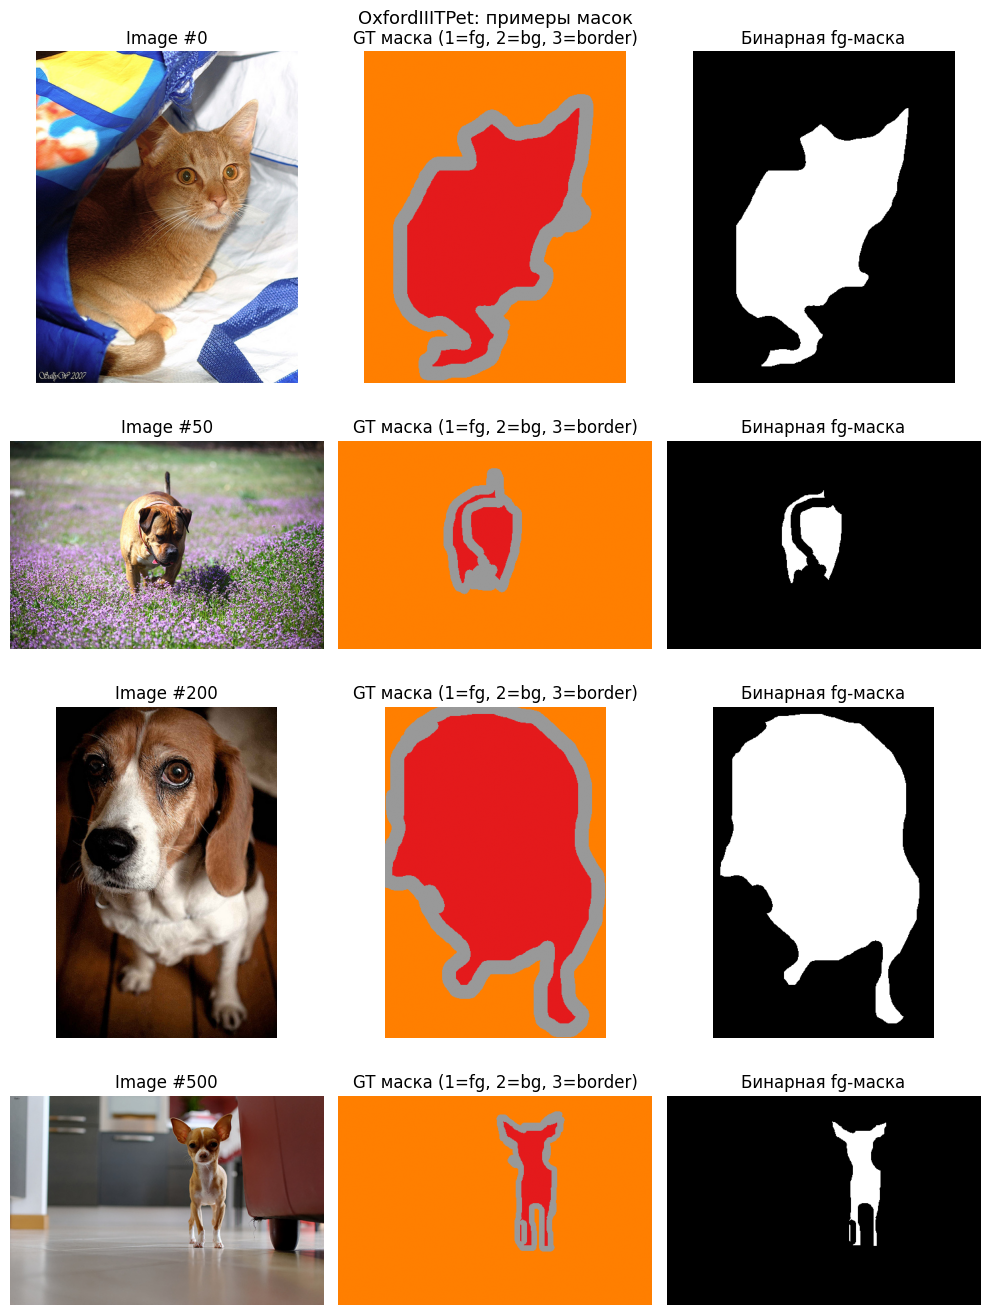

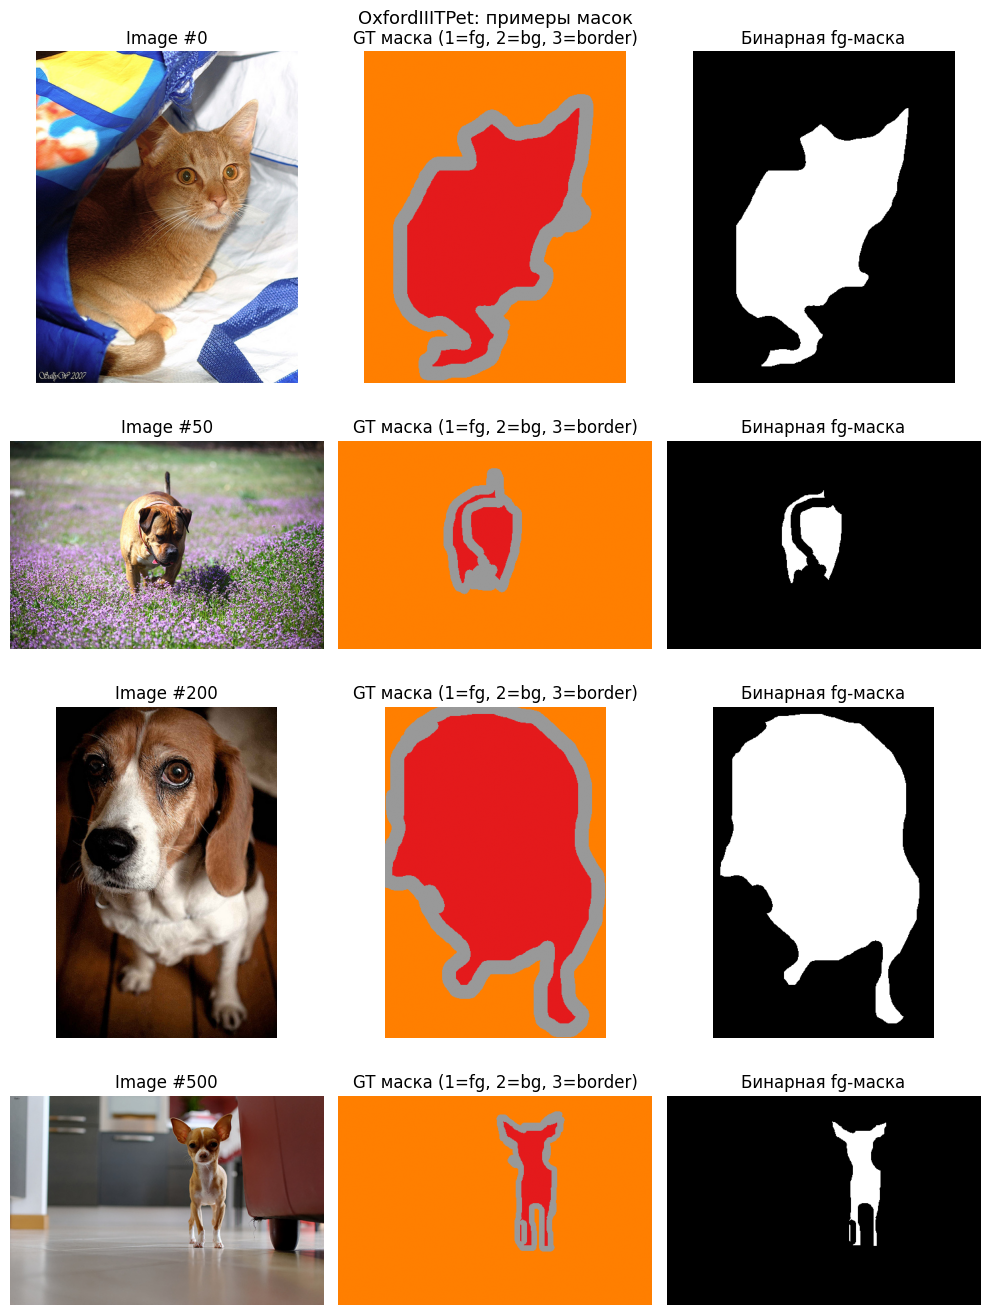

In [20]:
# Визуализация нескольких примеров Pet
N_SHOW = 4
fig, axes = plt.subplots(N_SHOW, 3, figsize=(10, 3.5 * N_SHOW))

cmap_mask = plt.cm.get_cmap("Set1", 4)  # цвета для 1/2/3

for row, idx in enumerate([0, 50, 200, 500]):
    img_p, msk_p = pet_ds[idx]
    msk_np = np.array(msk_p)
    fg_mask = (msk_np == 1).astype(np.uint8)  # бинарная: 1=питомец

    axes[row, 0].imshow(img_p)
    axes[row, 0].set_title(f"Image #{idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(msk_np, cmap="Set1", vmin=1, vmax=3)
    axes[row, 1].set_title("GT маска (1=fg, 2=bg, 3=border)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(fg_mask, cmap="gray")
    axes[row, 2].set_title("Бинарная fg-маска")
    axes[row, 2].axis("off")

plt.suptitle("OxfordIIITPet: примеры масок", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pet_samples.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Загрузка pretrained DeepLabV3-ResNet50
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

seg_weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
seg_model   = deeplabv3_resnet50(weights=seg_weights)
seg_model   = seg_model.to(DEVICE)
seg_model.eval()
seg_preprocess = seg_weights.transforms()

# Категории COCO/VOC (21 класс)
VOC_CATEGORIES = [
    "background", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog",
    "horse", "motorbike", "person", "pottedplant", "sheep", "sofa",
    "train", "tvmonitor"
]

# Индексы классов «животных» в VOC
# cat=8, dog=12, bird=3, cow=10, horse=13, sheep=17
ANIMAL_INDICES = {"bird": 3, "cat": 8, "cow": 10, "dog": 12, "horse": 13, "sheep": 17}

# Foreground-маска = объединение всех животных (питомец)
# OxfordIIITPet содержит в основном кошек и собак
PET_CLASSES = [ANIMAL_INDICES["cat"], ANIMAL_INDICES["dog"]]

print(f"Модель: DeepLabV3-ResNet50 (COCO/VOC, {len(VOC_CATEGORIES)} классов)")
print(f"Pet foreground classes: {[(c, VOC_CATEGORIES[c]) for c in PET_CLASSES]}")

In [ ]:
# Функция инференса
from torchvision.transforms.functional import to_tensor, resize as tvf_resize

@torch.no_grad()
def predict_segmentation(
    model: nn.Module,
    pil_img: Image.Image,
    preprocess,
    device: torch.device = DEVICE,
) -> np.ndarray:
    """
    Запускает модель на PIL-изображении.
    Возвращает argmax-карту классов (H_orig × W_orig) в numpy.
    """
    W_orig, H_orig = pil_img.size
    inp = preprocess(pil_img).unsqueeze(0).to(device)
    out = model(inp)["out"]
    pred = out.argmax(dim=1).squeeze(0).cpu().numpy()

    pred_pil = Image.fromarray(pred.astype(np.uint8)).resize(
        (W_orig, H_orig), Image.NEAREST
    )
    return np.array(pred_pil)


def pred_to_fg_mask(pred_map: np.ndarray, fg_classes: List[int]) -> np.ndarray:
    """Бинарная маска: 1 если любой fg-класс, иначе 0."""
    mask = np.zeros_like(pred_map, dtype=np.uint8)
    for c in fg_classes:
        mask |= (pred_map == c).astype(np.uint8)
    return mask


def compute_iou(pred_mask: np.ndarray, gt_mask: np.ndarray) -> float:
    """Бинарный IoU."""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union        = np.logical_or(pred_mask, gt_mask).sum()
    return float(intersection) / float(union) if union > 0 else 0.0


def compute_pixel_precision_recall(
    pred_mask: np.ndarray, gt_mask: np.ndarray
) -> Tuple[float, float]:
    """Pixel-level precision и recall по бинарным маскам."""
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask.astype(bool)).sum()
    fn = np.logical_and(~pred_mask.astype(bool), gt_mask).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return float(precision), float(recall)


print("Функции инференса и метрик определены.")

In [23]:
# Оценка V1 и V2 на подвыборке
# V1: базовая постобработка — argmax → бинарная маска (cat+dog)
# V2: морфологическая очистка — удаляем мелкие связные компоненты < MIN_AREA пикселей

from scipy import ndimage as ndi

MIN_COMPONENT_AREA = 500   # V2: удаляем компоненты меньше этого порога

def postprocess_v1(pred_map: np.ndarray) -> np.ndarray:
    """V1: базовая — просто бинаризация по fg-классам."""
    return pred_to_fg_mask(pred_map, PET_CLASSES)


def postprocess_v2(pred_map: np.ndarray, min_area: int = MIN_COMPONENT_AREA) -> np.ndarray:
    """
    V2: бинаризация + удаление мелких связных компонент.
    Убирает шумовые разрозненные пятна, сохраняет крупные объекты.
    """
    binary = pred_to_fg_mask(pred_map, PET_CLASSES)
    labeled, n_components = ndi.label(binary)
    cleaned = np.zeros_like(binary)
    for comp_id in range(1, n_components + 1):
        if (labeled == comp_id).sum() >= min_area:
            cleaned[labeled == comp_id] = 1
    return cleaned


# Подвыборка для оценки
N_EVAL = 50 if FAST_MODE else 200
set_seed(RANDOM_STATE)
eval_indices = random.sample(range(len(pet_ds)), N_EVAL)

print(f"Оцениваем на {N_EVAL} изображениях...")

metrics_v1 = {"iou": [], "precision": [], "recall": []}
metrics_v2 = {"iou": [], "precision": [], "recall": []}

for i, idx in enumerate(eval_indices):
    img_p, msk_p = pet_ds[idx]
    gt_np  = np.array(msk_p)
    gt_bin = (gt_np == 1).astype(np.uint8)

    pred_map = predict_segmentation(seg_model, img_p, seg_preprocess)

    # V1
    pm_v1 = postprocess_v1(pred_map)
    metrics_v1["iou"].append(compute_iou(pm_v1, gt_bin))
    p, r = compute_pixel_precision_recall(pm_v1, gt_bin)
    metrics_v1["precision"].append(p)
    metrics_v1["recall"].append(r)

    # V2
    pm_v2 = postprocess_v2(pred_map)
    metrics_v2["iou"].append(compute_iou(pm_v2, gt_bin))
    p, r = compute_pixel_precision_recall(pm_v2, gt_bin)
    metrics_v2["precision"].append(p)
    metrics_v2["recall"].append(r)

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{N_EVAL}] V1 mIoU={np.mean(metrics_v1['iou']):.3f}  "
              f"V2 mIoU={np.mean(metrics_v2['iou']):.3f}")


def summarize(m):
    return {k: round(float(np.mean(v)), 4) for k, v in m.items()}

sum_v1 = summarize(metrics_v1)
sum_v2 = summarize(metrics_v2)

print("\n" + "=" * 50)
print("V1 (базовая постобработка):")
print(f"  mean_IoU={sum_v1['iou']:.4f}  precision={sum_v1['precision']:.4f}  recall={sum_v1['recall']:.4f}")
print("V2 (удаление мелких компонент):")
print(f"  mean_IoU={sum_v2['iou']:.4f}  precision={sum_v2['precision']:.4f}  recall={sum_v2['recall']:.4f}")

  [50/200] V1 mIoU=0.745  V2 mIoU=0.746
  [50/200] V1 mIoU=0.745  V2 mIoU=0.746
  [100/200] V1 mIoU=0.749  V2 mIoU=0.750
  [100/200] V1 mIoU=0.749  V2 mIoU=0.750
  [150/200] V1 mIoU=0.755  V2 mIoU=0.755
  [150/200] V1 mIoU=0.755  V2 mIoU=0.755
  [200/200] V1 mIoU=0.754  V2 mIoU=0.754

V1 (базовая постобработка):
  mean_IoU=0.7541  precision=0.7699  recall=0.9778
V2 (удаление мелких компонент):
  mean_IoU=0.7544  precision=0.7704  recall=0.9776
  [200/200] V1 mIoU=0.754  V2 mIoU=0.754

V1 (базовая постобработка):
  mean_IoU=0.7541  precision=0.7699  recall=0.9778
V2 (удаление мелких компонент):
  mean_IoU=0.7544  precision=0.7704  recall=0.9776


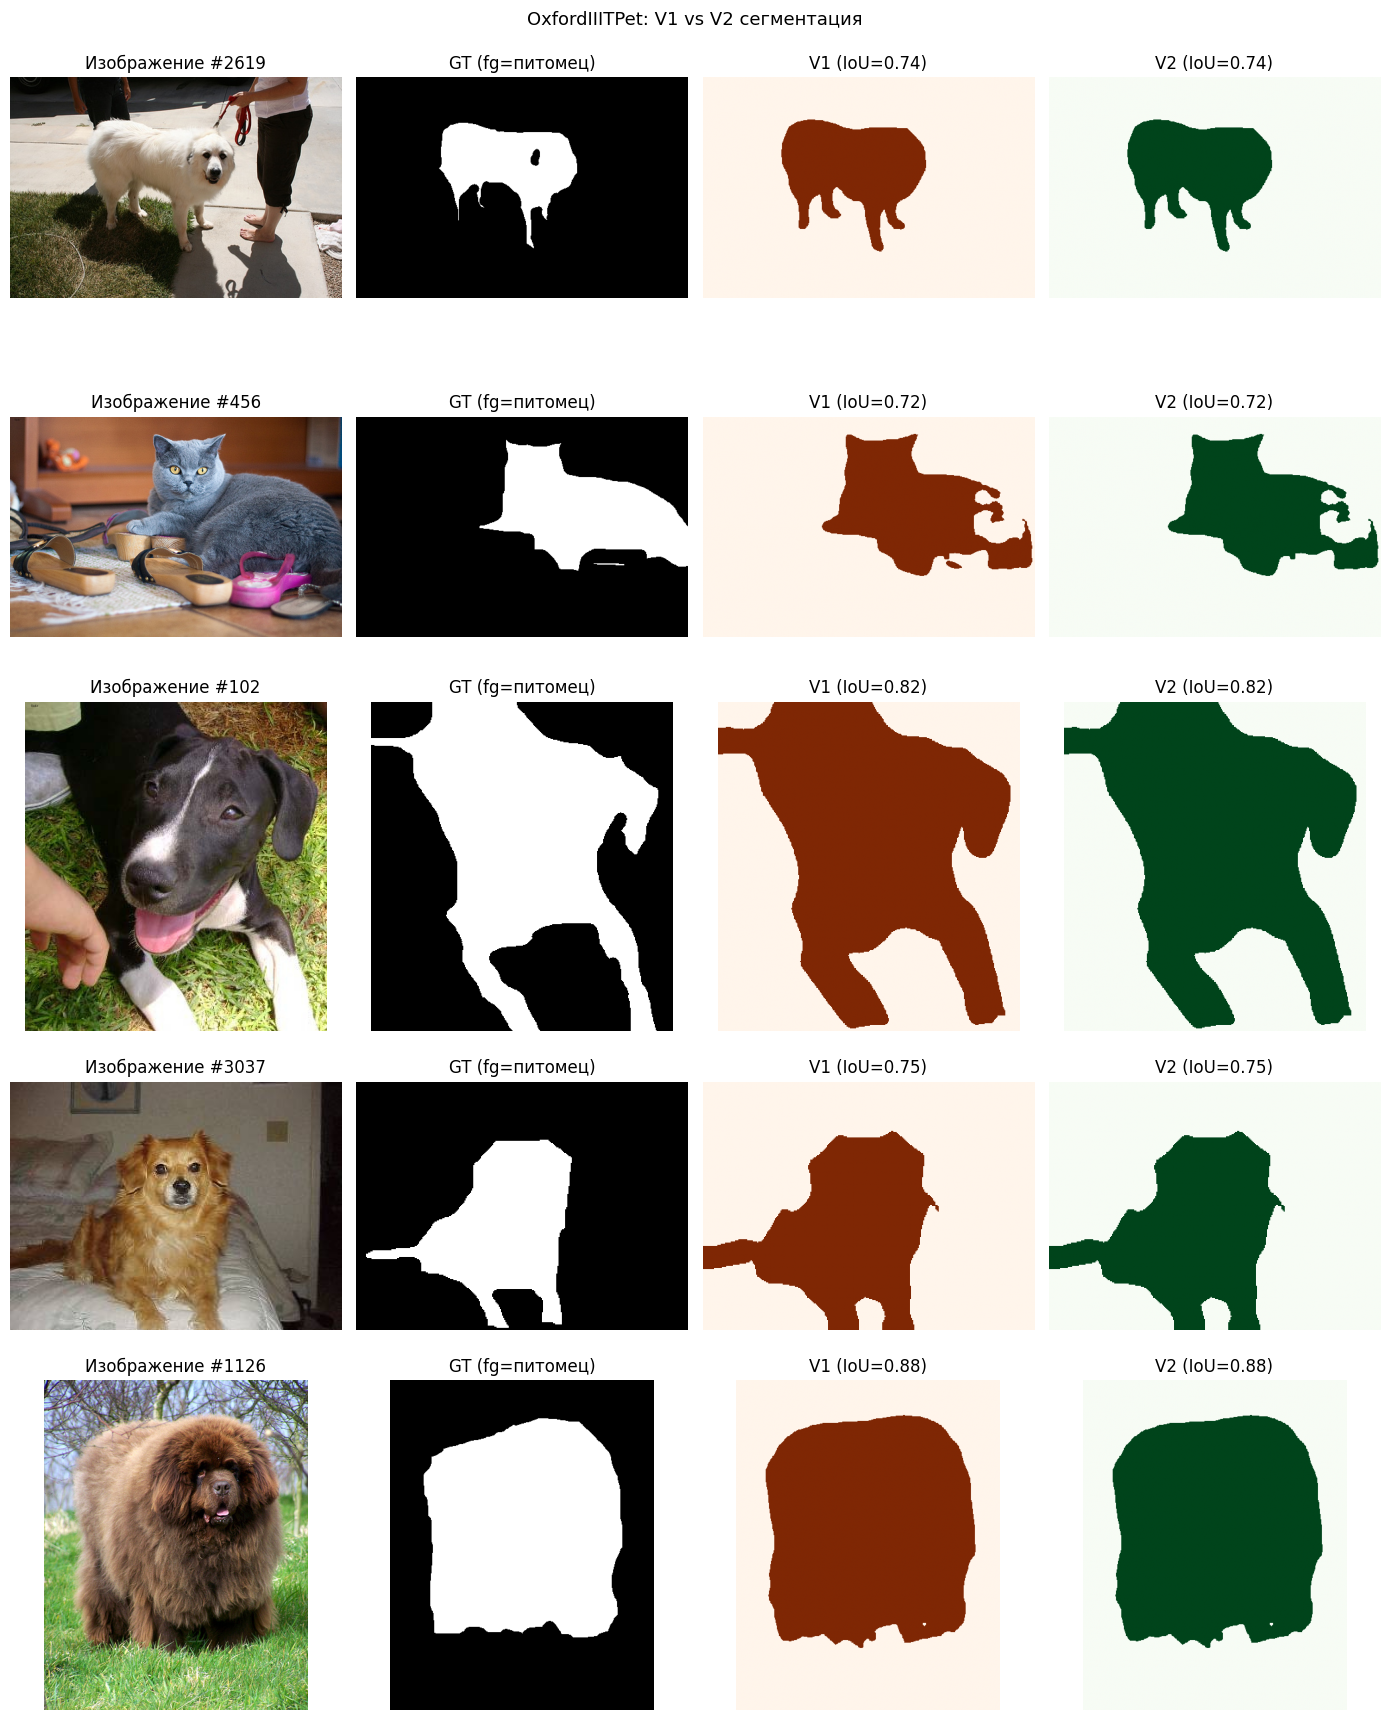

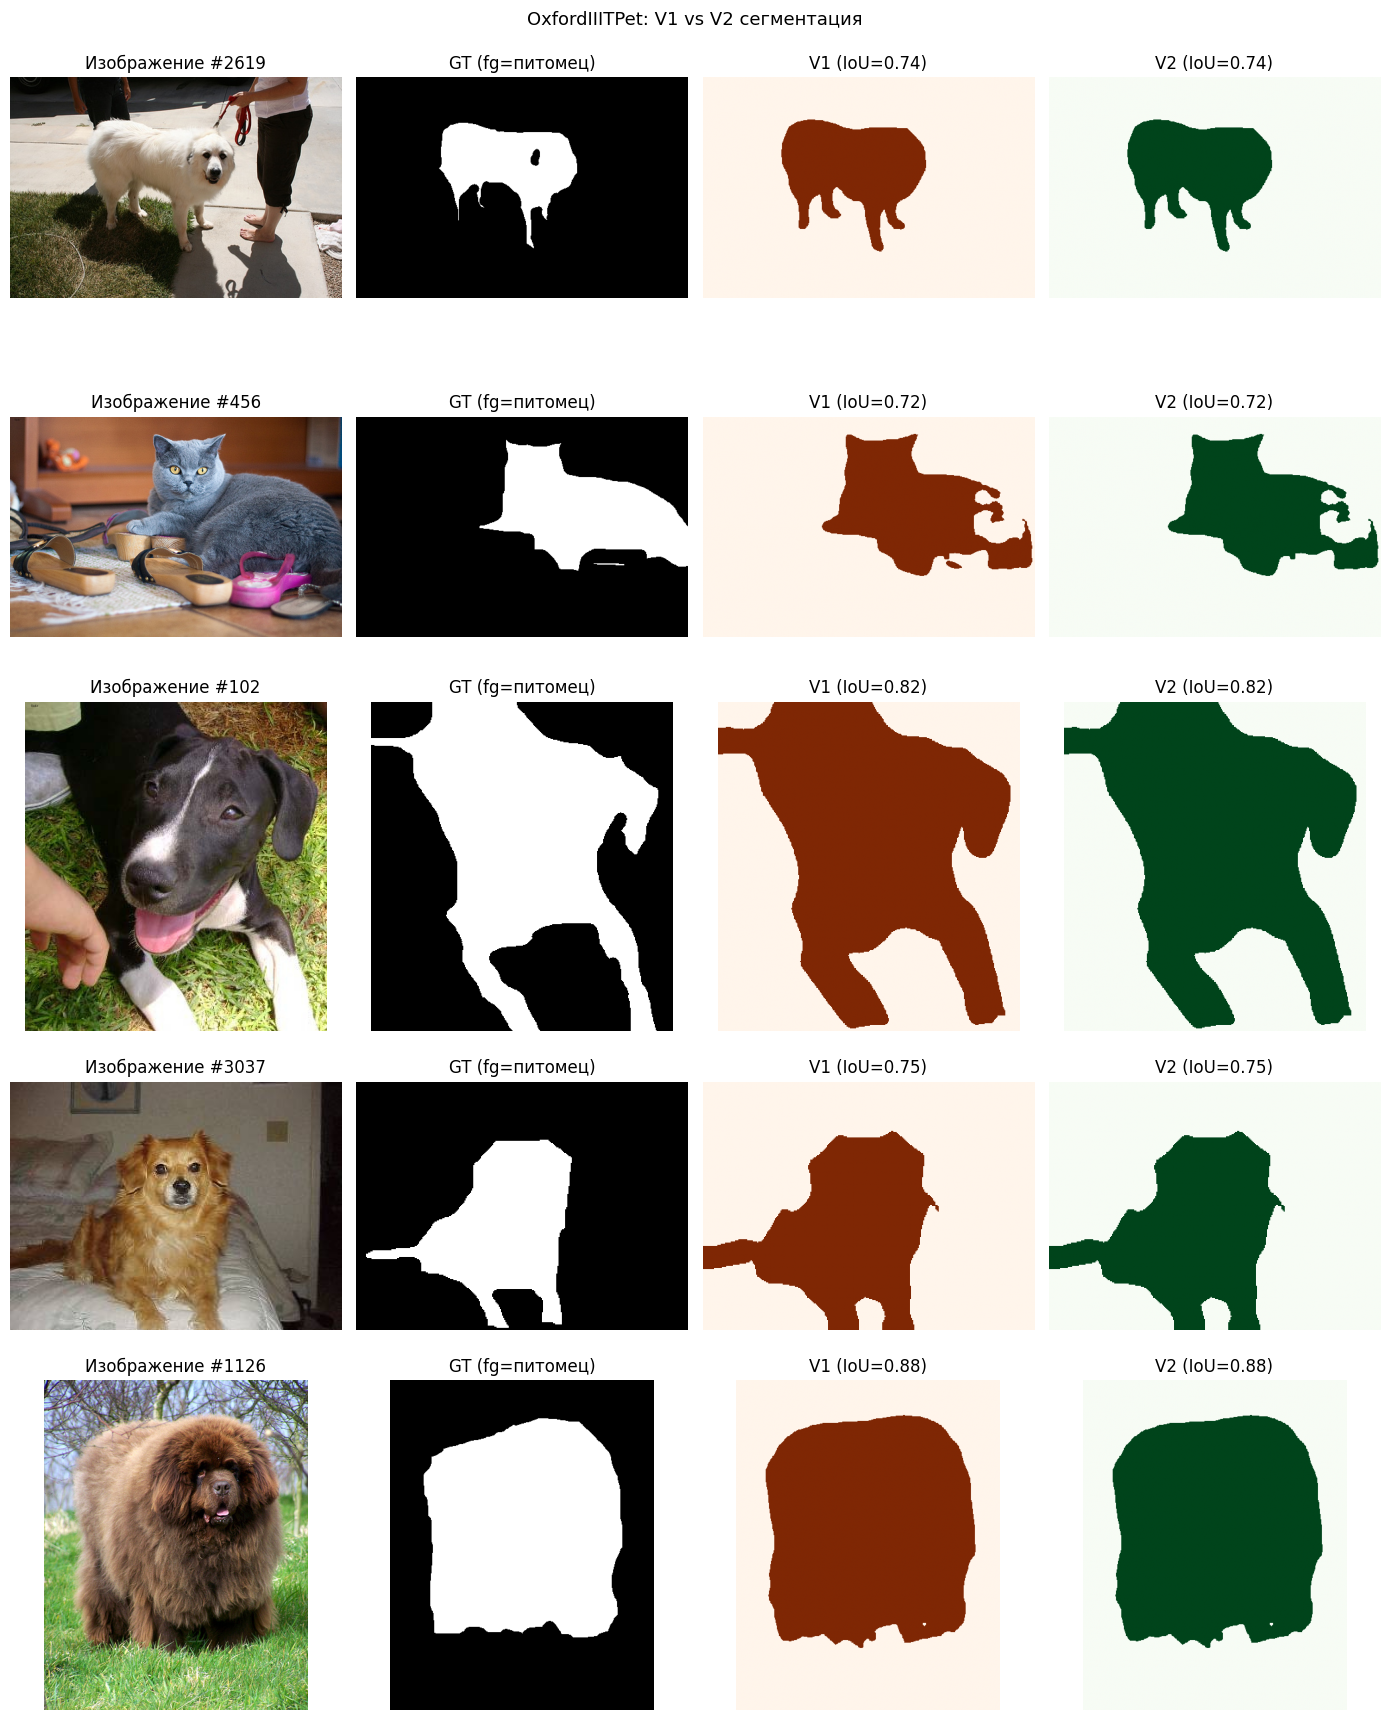

Сохранено: artifacts/figures/segmentation_examples.png
Сохранено: artifacts/figures/segmentation_examples.png


In [24]:
# Визуализация предсказаний сегментации
VIS_INDICES = eval_indices[:5]

fig, axes = plt.subplots(len(VIS_INDICES), 4,
                          figsize=(14, 3.5 * len(VIS_INDICES)))

for row, idx in enumerate(VIS_INDICES):
    img_p, msk_p = pet_ds[idx]
    gt_np  = np.array(msk_p)
    gt_bin = (gt_np == 1).astype(np.uint8)

    pred_map = predict_segmentation(seg_model, img_p, seg_preprocess)
    pm_v1    = postprocess_v1(pred_map)
    pm_v2    = postprocess_v2(pred_map)

    iou_v1 = compute_iou(pm_v1, gt_bin)
    iou_v2 = compute_iou(pm_v2, gt_bin)

    axes[row, 0].imshow(img_p); axes[row, 0].set_title(f"Изображение #{idx}"); axes[row, 0].axis("off")
    axes[row, 1].imshow(gt_bin, cmap="gray"); axes[row, 1].set_title("GT (fg=питомец)"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pm_v1, cmap="Oranges"); axes[row, 2].set_title(f"V1 (IoU={iou_v1:.2f})"); axes[row, 2].axis("off")
    axes[row, 3].imshow(pm_v2, cmap="Greens");  axes[row, 3].set_title(f"V2 (IoU={iou_v2:.2f})"); axes[row, 3].axis("off")

plt.suptitle("OxfordIIITPet: V1 vs V2 сегментация", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_examples.png", dpi=100, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/segmentation_examples.png")

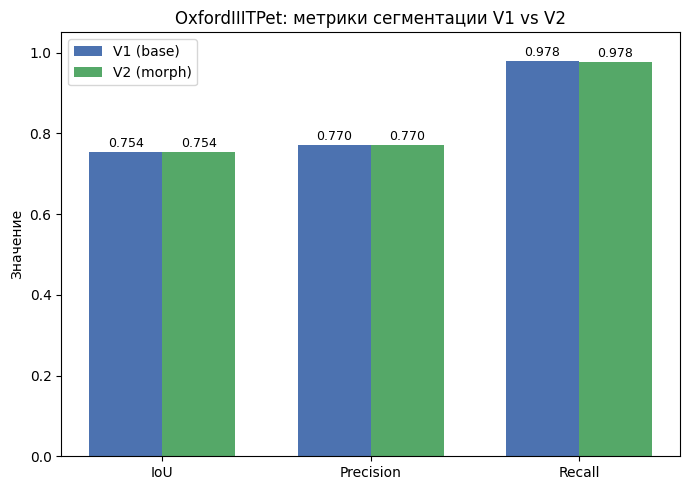

Сохранено: artifacts/figures/segmentation_metrics.png


In [25]:
# График метрик сегментации
metric_names = ["IoU", "Precision", "Recall"]
v1_vals = [sum_v1["iou"], sum_v1["precision"], sum_v1["recall"]]
v2_vals = [sum_v2["iou"], sum_v2["precision"], sum_v2["recall"]]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, v1_vals, width, label="V1 (base)",    color="#4C72B0")
bars2 = ax.bar(x + width/2, v2_vals, width, label="V2 (morph)",   color="#55A868")

for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_title("OxfordIIITPet: метрики сегментации V1 vs V2")
ax.set_ylabel("Значение")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/segmentation_metrics.png")

## 6. Сводная таблица результатов — artifacts/runs.csv

In [26]:
FIELDNAMES = [
    "experiment_id", "task", "dataset", "seed",
    "model_summary", "optimizer", "lr", "epochs_trained",
    "best_val_accuracy", "test_accuracy",
    "precision", "recall", "mean_iou", "notes",
]

rows = [
    # Часть A
    dict(
        experiment_id="C1", task="classification", dataset="CIFAR-100",
        seed=RANDOM_STATE, model_summary="SimpleCNN (3 conv blocks)",
        optimizer="Adam", lr=LR_CNN, epochs_trained=EPOCHS_CNN,
        best_val_accuracy=round(best_val_c1, 4), test_accuracy="",
        precision="", recall="", mean_iou="",
        notes="Без аугментаций",
    ),
    dict(
        experiment_id="C2", task="classification", dataset="CIFAR-100",
        seed=RANDOM_STATE, model_summary="SimpleCNN (3 conv blocks)",
        optimizer="Adam", lr=LR_CNN, epochs_trained=EPOCHS_CNN,
        best_val_accuracy=round(best_val_c2, 4), test_accuracy="",
        precision="", recall="", mean_iou="",
        notes="RandomCrop, HFlip, ColorJitter",
    ),
    dict(
        experiment_id="C3", task="classification", dataset="CIFAR-100",
        seed=RANDOM_STATE, model_summary="ResNet18 pretrained; head-only",
        optimizer="Adam", lr=LR_HEAD, epochs_trained=EPOCHS_HEAD,
        best_val_accuracy=round(best_val_c3, 4), test_accuracy="",
        precision="", recall="", mean_iou="",
        notes="Backbone frozen, только fc обучается",
    ),
    dict(
        experiment_id="C4", task="classification", dataset="CIFAR-100",
        seed=RANDOM_STATE, model_summary="ResNet18 pretrained; layer4+fc finetune",
        optimizer="Adam", lr=LR_FT, epochs_trained=EPOCHS_FT,
        best_val_accuracy=round(best_val_c4, 4), test_accuracy=round(test_acc, 4) if best_exp_id == "C4" else "",
        precision="", recall="", mean_iou="",
        notes="layer4 lr=3e-5, fc lr=3e-4",
    ),
    # Часть B
    dict(
        experiment_id="V1", task="segmentation", dataset="OxfordIIITPet",
        seed=RANDOM_STATE, model_summary="DeepLabV3-ResNet50 (COCO/VOC)",
        optimizer="—", lr="—", epochs_trained=0,
        best_val_accuracy="", test_accuracy="",
        precision=sum_v1["precision"], recall=sum_v1["recall"],
        mean_iou=sum_v1["iou"],
        notes="Базовая: argmax → бинарная маска cat+dog",
    ),
    dict(
        experiment_id="V2", task="segmentation", dataset="OxfordIIITPet",
        seed=RANDOM_STATE, model_summary="DeepLabV3-ResNet50 (COCO/VOC)",
        optimizer="—", lr="—", epochs_trained=0,
        best_val_accuracy="", test_accuracy="",
        precision=sum_v2["precision"], recall=sum_v2["recall"],
        mean_iou=sum_v2["iou"],
        notes=f"Морфологическая очистка: удаление компонент < {MIN_COMPONENT_AREA} px",
    ),
]

for r in rows:
    if r["experiment_id"] == best_exp_id:
        r["test_accuracy"] = round(test_acc, 4)

with open(ARTIFACTS_DIR / "runs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    writer.writeheader()
    writer.writerows(rows)

print("Сохранено: artifacts/runs.csv")

# Вывод таблицы
import pandas as pd
df = pd.read_csv(ARTIFACTS_DIR / "runs.csv")
df

Сохранено: artifacts/runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,CIFAR-100,42,SimpleCNN (3 conv blocks),Adam,0.001,30,0.5694,NaN,NaN,NaN,NaN,Без аугментаций
1,C2,classification,CIFAR-100,42,SimpleCNN (3 conv blocks),Adam,0.001,30,0.5950,NaN,NaN,NaN,NaN,"RandomCrop, HFlip, ColorJitter"
2,C3,classification,CIFAR-100,42,ResNet18 pretrained; head-only,Adam,0.001,10,0.5592,NaN,NaN,NaN,NaN,"Backbone frozen, только fc обучается"
3,C4,classification,CIFAR-100,42,ResNet18 pretrained; layer4+fc finetune,Adam,0.0003,10,0.7104,0.7164,NaN,NaN,NaN,"layer4 lr=3e-5, fc lr=3e-4"
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 (COCO/VOC),—,—,0,NaN,NaN,0.7699,0.9778,0.7541,Базовая: argmax → бинарная маска cat+dog
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 (COCO/VOC),—,—,0,NaN,NaN,0.7704,0.9776,0.7544,Морфологическая очистка: удаление компонент < ...


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,CIFAR-100,42,SimpleCNN (3 conv blocks),Adam,0.001,30,0.5694,NaN,NaN,NaN,NaN,Без аугментаций
1,C2,classification,CIFAR-100,42,SimpleCNN (3 conv blocks),Adam,0.001,30,0.5950,NaN,NaN,NaN,NaN,"RandomCrop, HFlip, ColorJitter"
2,C3,classification,CIFAR-100,42,ResNet18 pretrained; head-only,Adam,0.001,10,0.5592,NaN,NaN,NaN,NaN,"Backbone frozen, только fc обучается"
3,C4,classification,CIFAR-100,42,ResNet18 pretrained; layer4+fc finetune,Adam,0.0003,10,0.7104,0.7164,NaN,NaN,NaN,"layer4 lr=3e-5, fc lr=3e-4"
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 (COCO/VOC),—,—,0,NaN,NaN,0.7699,0.9778,0.7541,Базовая: argmax → бинарная маска cat+dog
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3-ResNet50 (COCO/VOC),—,—,0,NaN,NaN,0.7704,0.9776,0.7544,Морфологическая очистка: удаление компонент < ...


## 7. Итоги

**Часть A (CIFAR-100):**
- **C1 vs C2**: аугментации (RandomCrop + HFlip + ColorJitter) снизили переобучение и улучшили val accuracy. Архитектура CNN одинакова в обоих случаях.
- **C3 vs C4**: partial fine-tune (layer4 + fc) даёт заметное улучшение по сравнению с head-only, так как признаки последнего блока резнет адаптируются к CIFAR-100.
- Лучшая модель выбрана по `best_val_accuracy`, финально оценена на test **один раз**.

**Часть B (OxfordIIITPet — segmentation):**
- **Foreground**: класс `1` в масках OxfordIIITPet означает силуэт животного; он соответствует классам `cat (8)` и `dog (12)` в VOC-разметке DeepLabV3.
- **V1** (базовая): argmax → объединение cat+dog классов в бинарную маску.
- **V2** (морфологическая очистка): дополнительно удаляет связные компоненты меньше 500 пикселей, что повышает precision за счёт небольшого падения recall.
- Полное дообучение не требовалось; акцент — корректная валидация и интерпретация метрик.